In [6]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import os
import pathlib
import json

from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [2]:
df = pd.DataFrame()
path = pathlib.Path('/home/ganesh/soccermatics/data/wyscout/events_England.json')
with open(path) as f:
    data = json.load(f)
df = pd.concat([df, pd.DataFrame(data)])
df

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,1H,2.758649,85,177959171
1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,1H,4.946850,83,177959172
2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,1H,6.542188,82,177959173
3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,1H,8.143395,82,177959174
4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,1H,10.302366,85,177959175
...,...,...,...,...,...,...,...,...,...,...,...,...
643145,5,Ball out of the field,[],0,"[{'y': 32, 'x': 0}, {'y': 100, 'x': 100}]",2500098,Interruption,1623,2H,2796.732525,50,251596409
643146,3,Corner,"[{'id': 302}, {'id': 801}, {'id': 1801}]",70965,"[{'y': 100, 'x': 100}, {'y': 47, 'x': 88}]",2500098,Free Kick,1633,2H,2829.821084,30,251596232
643147,1,Air duel,"[{'id': 701}, {'id': 1802}]",7919,"[{'y': 53, 'x': 12}, {'y': 50, 'x': 14}]",2500098,Duel,1623,2H,2831.211419,10,251596410
643148,1,Air duel,"[{'id': 703}, {'id': 1801}]",8005,"[{'y': 47, 'x': 88}, {'y': 50, 'x': 86}]",2500098,Duel,1633,2H,2832.434399,10,251596234


In [3]:
#get events from match
match_id = 2500045
#get passes from this match
match_events = df.loc[df["matchId"] == match_id]
next_event = match_events.shift(-1, fill_value=0)
match_events["nextEvent"] = next_event["subEventName"]
match_events["kickedOut"] = match_events.apply(lambda x: 1 if x.nextEvent == "Ball out of the field" else 0, axis = 1)
passes = match_events.loc[match_events["eventName"] == "Pass"]
#change coords to better find progressive
passes["x"] = passes.positions.apply(lambda cell: (cell[0]['x']) * 105/100)
passes["y"] = passes.positions.apply(lambda cell: (100 - cell[0]['y']) * 68/100)
passes["end_x"] = passes.positions.apply(lambda cell: (cell[1]['x']) * 105/100)
passes["end_y"] = passes.positions.apply(lambda cell: (100 - cell[1]['y']) * 68/100)
delete_passes = passes.loc[passes["kickedOut"] == 1]
passes = passes.drop(delete_passes.index)
passes = passes.loc[(((passes["end_x"] != 0) & (passes["end_y"] != 68)) & ((passes["end_x"] != 105) & (passes["end_y"] != 0)))]
passes

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,nextEvent,kickedOut,x,y,end_x,end_y
552129,8,Simple pass,[{'id': 1801}],7934,"[{'y': 50, 'x': 50}, {'y': 70, 'x': 44}]",2500045,Pass,1611,1H,2.036874,85,240776909,Simple pass,0,52.50,34.00,46.20,20.40
552130,8,Simple pass,[{'id': 1801}],70122,"[{'y': 70, 'x': 44}, {'y': 89, 'x': 28}]",2500045,Pass,1611,1H,7.181832,85,240776910,Simple pass,0,46.20,20.40,29.40,7.48
552131,8,Simple pass,[{'id': 1801}],7938,"[{'y': 89, 'x': 28}, {'y': 59, 'x': 9}]",2500045,Pass,1611,1H,11.786454,85,240776911,Launch,0,29.40,7.48,9.45,27.88
552132,8,Launch,[{'id': 1801}],7910,"[{'y': 59, 'x': 9}, {'y': 75, 'x': 68}]",2500045,Pass,1611,1H,20.541311,84,240776914,Ground loose ball duel,0,9.45,27.88,71.40,17.00
552135,8,Head pass,[{'id': 1802}],7905,"[{'y': 80, 'x': 66}, {'y': 56, 'x': 90}]",2500045,Pass,1611,1H,24.454220,82,240776919,Hand pass,0,69.30,13.60,94.50,29.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553721,8,Cross,"[{'id': 302}, {'id': 401}, {'id': 1801}]",38021,"[{'y': 8, 'x': 79}, {'y': 38, 'x': 89}]",2500045,Pass,1625,2H,2986.309742,80,240778546,Shot,0,82.95,62.56,93.45,42.16
553733,8,Launch,[{'id': 1801}],8464,"[{'y': 11, 'x': 10}, {'y': 32, 'x': 31}]",2500045,Pass,1625,2H,3060.387028,84,240778552,Air duel,0,10.50,60.52,32.55,46.24
553736,8,Head pass,[{'id': 1801}],8307,"[{'y': 33, 'x': 39}, {'y': 47, 'x': 47}]",2500045,Pass,1625,2H,3065.351093,82,240778553,Air duel,0,40.95,45.56,49.35,36.04
553739,8,Simple pass,[{'id': 1802}],70083,"[{'y': 51, 'x': 44}, {'y': 59, 'x': 68}]",2500045,Pass,1625,2H,3068.093975,85,240778555,Head pass,0,46.20,33.32,71.40,27.88


In [4]:
def is_progressive(x, y, end_x, end_y):
    start_dist = np.sqrt((105 - x)**2 + (34 - y)**2)
    end_dist = np.sqrt((105 - end_x)**2 + (34 - end_y)**2)
    #mark that passes to own half are not progressive
    thres = 100
    if x < 52.5 and end_x < 52.5:
        thres = 30
    elif x < 52.5 and end_x >= 52.5:
        thres = 15
    elif x >= 52.5 and end_x >= 52.5:
        thres = 10
    if thres > start_dist - end_dist:
        return False
    else:
        return True

In [5]:
passes["is_progressive"] = passes.apply(lambda row : is_progressive(row['x'], row['y'], row['end_x'], row['end_y']), axis = 1)

#keep united progressive passes
united_passes = passes.loc[passes["teamId"] != 1625]
united_progressive = united_passes.loc[united_passes["is_progressive"] == True]

united_progressive["angle"] = np.arctan2(united_progressive["end_y"] - united_progressive["y"], united_progressive["end_x"] - united_progressive["x"])
united_progressive

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,nextEvent,kickedOut,x,y,end_x,end_y,is_progressive,angle
552132,8,Launch,[{'id': 1801}],7910,"[{'y': 59, 'x': 9}, {'y': 75, 'x': 68}]",2500045,Pass,1611,1H,20.541311,84,240776914,Ground loose ball duel,0,9.45,27.88,71.40,17.00,True,-0.173853
552135,8,Head pass,[{'id': 1802}],7905,"[{'y': 80, 'x': 66}, {'y': 56, 'x': 90}]",2500045,Pass,1611,1H,24.454220,82,240776919,Hand pass,0,69.30,13.60,94.50,29.92,True,0.574700
552162,8,Simple pass,[{'id': 1801}],7938,"[{'y': 95, 'x': 39}, {'y': 84, 'x': 53}]",2500045,Pass,1611,1H,90.957593,85,240776941,Simple pass,0,40.95,3.40,55.65,10.88,True,0.470697
552164,8,High pass,[{'id': 1802}],7938,"[{'y': 90, 'x': 37}, {'y': 71, 'x': 79}]",2500045,Pass,1611,1H,93.242079,83,240776945,Head pass,0,38.85,6.80,82.95,19.72,True,0.284995
552189,8,High pass,[{'id': 1802}],256998,"[{'y': 84, 'x': 22}, {'y': 57, 'x': 71}]",2500045,Pass,1611,1H,153.041670,83,240776966,Simple pass,0,23.10,10.88,74.55,29.24,True,0.342765
552209,8,Simple pass,[{'id': 1801}],7936,"[{'y': 48, 'x': 53}, {'y': 28, 'x': 66}]",2500045,Pass,1611,1H,231.598754,85,240776981,Smart pass,0,55.65,35.36,69.30,48.96,True,0.783563
552236,8,Launch,[{'id': 1802}],7939,"[{'y': 10, 'x': 21}, {'y': 37, 'x': 69}]",2500045,Pass,1611,1H,298.658795,84,240777009,Simple pass,0,22.05,61.20,72.45,42.84,True,-0.349344
552264,8,Head pass,[{'id': 1801}],7922,"[{'y': 53, 'x': 47}, {'y': 63, 'x': 70}]",2500045,Pass,1611,1H,396.711791,82,240777034,Simple pass,0,49.35,31.96,73.50,25.16,True,-0.274467
552271,8,Simple pass,[{'id': 1801}],3413,"[{'y': 94, 'x': 75}, {'y': 86, 'x': 92}]",2500045,Pass,1611,1H,413.673800,85,240777048,Ground loose ball duel,0,78.75,4.08,96.60,9.52,True,0.295820
552284,8,Simple pass,[{'id': 1801}],256998,"[{'y': 74, 'x': 32}, {'y': 96, 'x': 55}]",2500045,Pass,1611,1H,444.728094,85,240777059,Simple pass,0,33.60,17.68,57.75,2.72,True,-0.554607


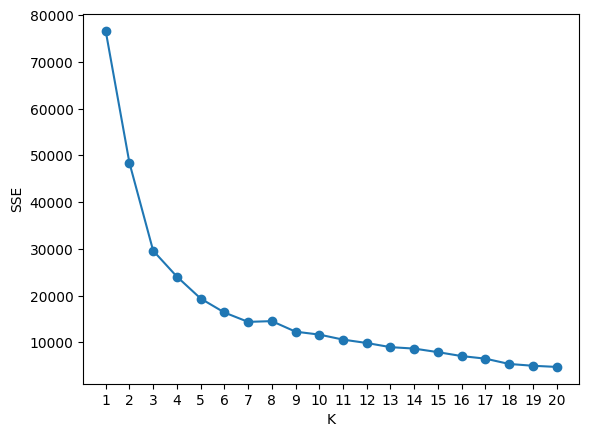

In [7]:
K = np.linspace(1, 20, 20)
X = united_progressive[["x", "y", "end_x", "end_y", "angle"]].values
elbow = {"sse": [], "k": [], "sil": []}
for k in K:
    cluster = KMeans(n_clusters = int(k), random_state = 2147)
    labels = cluster.fit_predict(X)
    elbow["sse"].append(cluster.inertia_)
    elbow["k"].append(k)

plt.scatter(elbow["k"], elbow["sse"])
plt.plot(elbow["k"], elbow["sse"])
plt.xticks(np.linspace(1, 20, 20))
plt.xlabel("K")
plt.ylabel("SSE")
plt.show()

In [8]:
def compute_inertia(a, X):
    W = [np.mean(pairwise_distances(X[a == c, :])) for c in np.unique(a)]
    return np.mean(W)

def compute_gap(clustering, data, k_max, n_references=5):
    if len(data.shape) == 1:
        data = data.reshape(-1, 1)
    reference = np.random.rand(*data.shape)
    reference_inertia = []
    for k in range(1, k_max+1):
        local_inertia = []
        for _ in range(n_references):
            clustering.n_clusters = k
            assignments = clustering.fit_predict(reference)
            local_inertia.append(compute_inertia(assignments, reference))
        reference_inertia.append(np.mean(local_inertia))

    ondata_inertia = []
    for k in range(1, k_max+1):
        clustering.n_clusters = k
        assignments = clustering.fit_predict(data)
        ondata_inertia.append(compute_inertia(assignments, data))

    gap = np.log(reference_inertia)-np.log(ondata_inertia)
    return gap, np.log(reference_inertia), np.log(ondata_inertia)

Text(0.5, 0, 'k')

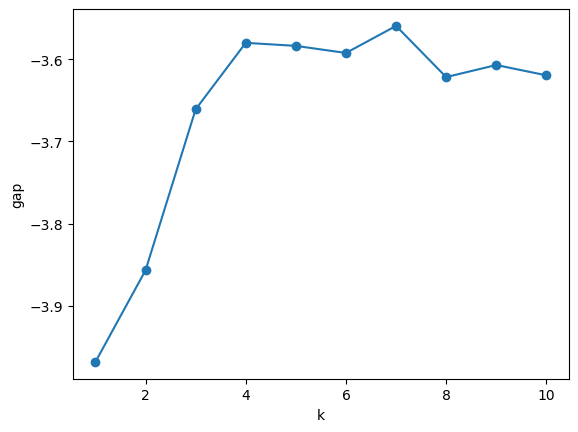

In [9]:
k_max = 10
gap, reference_inertia, ondata_inertia = compute_gap(KMeans(random_state = 2147), X, k_max)

plt.plot(range(1, k_max+1), gap, '-o')
plt.ylabel('gap')
plt.xlabel('k')

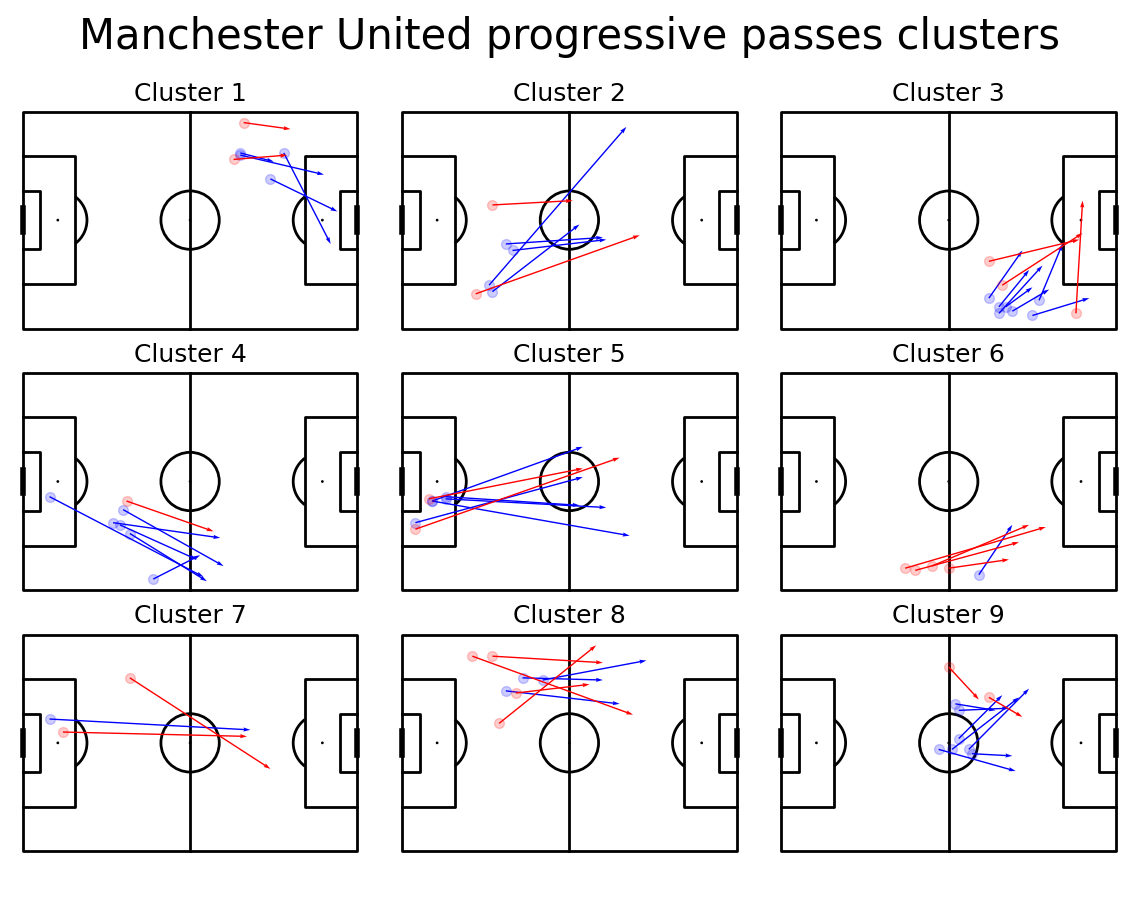

In [10]:
k = 9
cluster = KMeans(n_clusters = int(k), random_state = 2147)
labels = cluster.fit_predict(X)

united_progressive["label"] = labels


pitch = Pitch(line_color='black', pitch_type = "custom", pitch_length=105, pitch_width=68)
fig, axs = pitch.grid(ncols = 3, nrows = 3, grid_height=0.85, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0.04, endnote_space=0.01)

#for each player
for clust, ax in zip(np.linspace(0, k-1, k), axs['pitch'].flat[:k]):
    #put player name over the plot
    ax.text(52.5, 74, "Cluster " + str(int(clust+1)),
            ha='center', va='center', fontsize=18)
    #take only passes by this player
    clustered = united_progressive.loc[united_progressive["label"] == clust]
    #scatter
    correct = clustered.loc[clustered.apply (lambda x:{'id':1801} in x.tags, axis = 1)]
    pitch.scatter(correct.x, correct.y, alpha = 0.2, s = 50, color = "blue", ax=ax)
    #plot arrow
    pitch.arrows(correct.x, correct.y,
            correct.end_x, correct.end_y, color = "blue", ax=ax, width=1)
    incorrect = clustered.loc[clustered.apply (lambda x:{'id':1802} in x.tags, axis = 1)]
    pitch.scatter(incorrect.x, incorrect.y, alpha = 0.2, s = 50, color = "red", ax=ax)
    #plot arrow
    pitch.arrows(incorrect.x, incorrect.y,
            incorrect.end_x, incorrect.end_y, color = "red", ax=ax, width=1)

#Another way to set title using mplsoccer
axs['title'].text(0.5, 0.5, 'Manchester United progressive passes clusters', ha='center', va='center', fontsize=30)
plt.show()